In [2]:
from datetime import date, timedelta
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [3]:
cl = lambda x : x.drop('Unnamed: 0',axis=1,inplace=True)

In [4]:
forecasted = pd.read_csv('forecast_22072025.csv')
cl(forecasted)
forecasted.Material=forecasted.Material.astype(str)

In [5]:
forecasted.leadtime = forecasted.leadtime.astype(int)

In [6]:
forecasted.head()

,Material,Desc,leadtime,max_leadtime,year,forecasted_consum,Regular_req,One-off_req,Anticipated_consum,Buffer_stock,on_order_stock,Present_stock,net_req,oem
0,100000705,GAS REFRIGERATION 404A,100,100,2025,0.727273,0.0,0.727273,0.199253,0.199253,0.0,0.0,0.0,NaN
1,100000705,GAS REFRIGERATION 404A,100,100,2026,0.727273,0.0,0.727273,0.199253,0.199253,0.0,0.0,0.0,NaN
2,100000705,GAS REFRIGERATION 404A,100,100,2027,0.727273,0.0,0.727273,0.199253,0.199253,0.0,0.0,0.0,NaN
3,100000705,GAS REFRIGERATION 404A,100,100,2028,0.727273,0.0,0.727273,0.199253,0.199253,0.0,0.0,0.0,NaN
4,100000705,GAS REFRIGERATION 404A,100,100,2029,0.727273,0.0,0.727273,0.199253,0.199253,0.0,0.0,0.0,NaN


In [6]:
forecasted.oem.value_counts()

oem
atlas    110
ksb      100
Name: count, dtype: int64

In [27]:
def makedaywiseForecast(df_yearly,mat,oem,end_date=date.today()+timedelta(days=365*5),initial_stock=10):
    daywiseForecast = pd.DataFrame(columns=['Material','Desc','leadtime','date','daily_cons','Regular_req', 'One-off_req','Anticipated_consum','Buffer_stock','on_order_stock','present_stock','stock_after'])
    df=df_yearly.copy()
    df=df[(df['Material']==mat)&(df['oem']==oem)].reset_index(drop=True)
    consider_pre_order = False
    start_date = date.today()
    days = (end_date-start_date).days
    initial_stock = df.at[0,'forecasted_consum']*2
    daywiseForecast.at[0,'present_stock'] = initial_stock if df.at[0,'Buffer_stock'] < initial_stock else df.at[0,'Buffer_stock']*1.4
    daywiseForecast.at[0,'stock_after']=daywiseForecast.at[0,'present_stock']
    reorder_point=end_date+timedelta(days=2)
    reorder_index,present_stock_correction=days-1,0
    reorder_qty,updated_reorder_qty=0,0
    first_reorder=False
    leadtime = df['leadtime'].iloc[0]
    arrival={}
    for i in range(days):
        daywiseForecast.at[i,'date']=start_date+timedelta(days=i)
        daywiseForecast.at[i,'Anticipated_consum']=df.loc[df['year']==date.today().year,'Anticipated_consum'].iloc[0]
        daywiseForecast.at[i,'Regular_req']=df.loc[df['year']==date.today().year,'Regular_req'].iloc[0]
        daywiseForecast.at[i,'One-off_req']=df.loc[df['year']==date.today().year,'One-off_req'].iloc[0]
        daywiseForecast.at[i,'Buffer_stock']=df.loc[df['year']==date.today().year,'Buffer_stock'].iloc[0]
        daywiseForecast.at[i,'daily_cons']=df.loc[df['year']==date.today().year,'forecasted_consum'].iloc[0]/365
        if i>0:
            if i in arrival.keys():
                arrived_qty = arrival[i]
            else:
                arrived_qty=0
            daywiseForecast.at[i,'present_stock']=max(daywiseForecast.at[i-1,'present_stock']-daywiseForecast.at[i-1,'daily_cons'],0)
            daywiseForecast.at[i,'stock_after']=max(daywiseForecast.at[i-1,'stock_after']-daywiseForecast.at[i-1,'daily_cons'],0)+arrived_qty
            #print(daywiseForecast.at[i,'present_stock'],daywiseForecast.at[i,'stock_after'])
            if not first_reorder:
                if daywiseForecast.at[i,'present_stock']< daywiseForecast.at[i,'Buffer_stock']:
                    reorder_point = daywiseForecast.at[i,'date']
                    reorder_index=i
                    first_reorder = True
                    current_year=daywiseForecast.at[i,'date'].year
                    reorder_qty = daywiseForecast.at[i,'One-off_req']+ daywiseForecast.at[i,'Regular_req'] + daywiseForecast.at[i,'Anticipated_consum'] +  daywiseForecast.at[i,'Buffer_stock'] - daywiseForecast.at[i, 'present_stock']
                    arrival[i+leadtime]=reorder_qty
    daywiseForecast['Material']=mat
    daywiseForecast['Desc']=df.at[0,'Desc']
    daywiseForecast['leadtime']=df['leadtime'].iloc[0]
    date_for_stock_check = reorder_point+timedelta(days=(365+int(leadtime)))
    if date_for_stock_check < end_date:
        if daywiseForecast[daywiseForecast['date']==date_for_stock_check]['present_stock'].iloc[0] == 0:
            consider_pre_order = True
            present_stock_correction = daywiseForecast[daywiseForecast['date'].between(date.today(),reorder_point)]['daily_cons'].values.sum()
            updated_reorder_qty = reorder_qty - present_stock_correction
    result = {'reorder_point':reorder_point,
              'reorder_qty': np.ceil(reorder_qty),
              'updated_reorder_qty':np.ceil(updated_reorder_qty),
              'consider_pre_order':consider_pre_order,
              'One-off_req':np.ceil(daywiseForecast.at[reorder_index,'One-off_req']),
              'Regular_req':np.ceil(daywiseForecast.at[reorder_index,'Regular_req']),
              'Anticipated_consum':np.ceil(daywiseForecast.at[reorder_index,'Anticipated_consum']),
              'Buffer_stock':np.ceil(daywiseForecast.at[reorder_index,'Buffer_stock']),
              'present_stock':np.ceil(daywiseForecast.at[reorder_index, 'present_stock']+present_stock_correction)
             }
    return daywiseForecast.reset_index(drop=True), result

In [16]:
df,results = makedaywiseForecast(forecasted,'220003196','atlas')

In [17]:
df

,Material,Desc,leadtime,date,daily_cons,Regular_req,One-off_req,Anticipated_consum,Buffer_stock,on_order_stock,present_stock,stock_after
0,220003196,OIL FILTER,710,2025-07-23,0.035329,12.0,12.895051,48.425991,27.203259,NaN,38.084563,38.084563
1,220003196,OIL FILTER,710,2025-07-24,0.035329,12.0,12.895051,48.425991,27.203259,NaN,38.049234,38.049234
2,220003196,OIL FILTER,710,2025-07-25,0.035329,12.0,12.895051,48.425991,27.203259,NaN,38.013905,38.013905
3,220003196,OIL FILTER,710,2025-07-26,0.035329,12.0,12.895051,48.425991,27.203259,NaN,37.978576,37.978576
4,220003196,OIL FILTER,710,2025-07-27,0.035329,12.0,12.895051,48.425991,27.203259,NaN,37.943247,37.943247
...,...,...,...,...,...,...,...,...,...,...,...,...
1820,220003196,OIL FILTER,710,2030-07-17,0.035329,12.0,12.895051,48.425991,27.203259,NaN,0,47.142321
1821,220003196,OIL FILTER,710,2030-07-18,0.035329,12.0,12.895051,48.425991,27.203259,NaN,0,47.106992
1822,220003196,OIL FILTER,710,2030-07-19,0.035329,12.0,12.895051,48.425991,27.203259,NaN,0,47.071663
1823,220003196,OIL FILTER,710,2030-07-20,0.035329,12.0,12.895051,48.425991,27.203259,NaN,0,47.036334


In [18]:
results

{'reorder_point': datetime.date(2026, 5, 28),
 'reorder_qty': 74.0,
 'updated_reorder_qty': 63.0,
 'consider_pre_order': True,
 'One-off_req': 12.895051470396576,
 'Regular_req': 12.0,
 'Anticipated_consum': 48.42599053145636,
 'Buffer_stock': 27.203259266316064,
 'present_stock': 38.11989188098116}

In [19]:
def plot_req2(dff,tagw,mat,ro_p,leadtime):
  result=dff.copy()
  plt.figure(figsize=(12, 4))
  for t in tagw:
    t1=result[t].to_list()
    y1=result['date'].to_list()
    plt.plot(y1,t1, label=t,marker='o', linestyle='-')
  plt.axvline(x=ro_p, color='red', linestyle='--', label=f"reorder point at {ro_p.strftime('%d-%m-%Y')}")
  plt.axvline(x=ro_p+timedelta(days=leadtime), color='red', linestyle='--', label=f"delivery point at {(ro_p+timedelta(days=leadtime)).strftime('%d-%m-%Y')}")
  plt.hlines(max(t1), ro_p, ro_p+timedelta(days=leadtime), colors='k', linestyles='--', label='leadtime')
  plt.xticks(ticks=y1, labels=y1, rotation=45)
  plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
  plt.legend()
  plt.title(f"Forecast - {mat}")
  plt.tight_layout()
  plt.savefig(f"{mat}_1.png")
  plt.show()

In [28]:
ordering_required = {}
for mat in forecasted[forecasted.oem=='atlas'].Material.unique():
    _, ordering_required[mat] = makedaywiseForecast(forecasted,mat,'atlas')

ordering_required

{'220003196': {'reorder_point': datetime.date(2026, 5, 28),
  'reorder_qty': 74.0,
  'updated_reorder_qty': 63.0,
  'consider_pre_order': True,
  'One-off_req': 13.0,
  'Regular_req': 12.0,
  'Anticipated_consum': 49.0,
  'Buffer_stock': 28.0,
  'present_stock': 39.0},
 '220026293': {'reorder_point': datetime.date(2030, 7, 24),
  'reorder_qty': 0.0,
  'updated_reorder_qty': 0.0,
  'consider_pre_order': False,
  'One-off_req': 0.0,
  'Regular_req': 0.0,
  'Anticipated_consum': 0.0,
  'Buffer_stock': 0.0,
  'present_stock': 0.0},
 '220027684': {'reorder_point': datetime.date(2025, 11, 25),
  'reorder_qty': 1.0,
  'updated_reorder_qty': 1.0,
  'consider_pre_order': True,
  'One-off_req': 1.0,
  'Regular_req': 0.0,
  'Anticipated_consum': 1.0,
  'Buffer_stock': 1.0,
  'present_stock': 1.0},
 '220035026': {'reorder_point': datetime.date(2026, 2, 16),
  'reorder_qty': 1.0,
  'updated_reorder_qty': 1.0,
  'consider_pre_order': True,
  'One-off_req': 1.0,
  'Regular_req': 0.0,
  'Anticipated_c

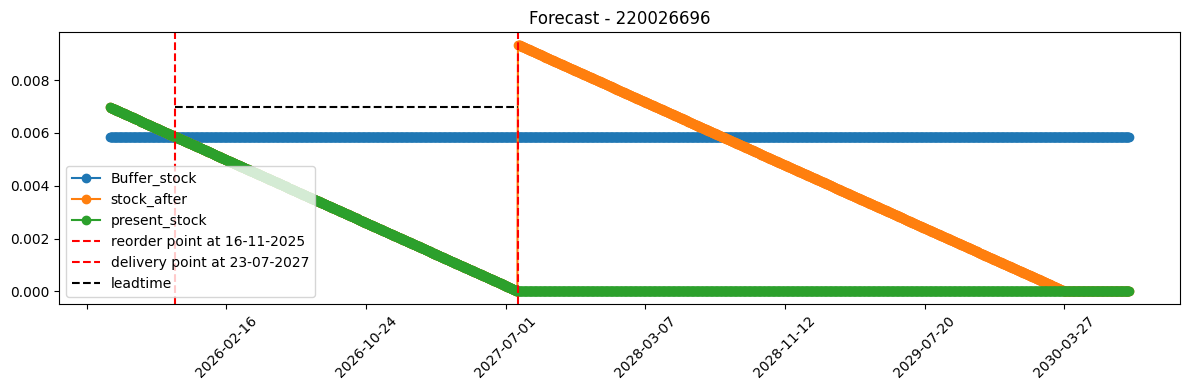

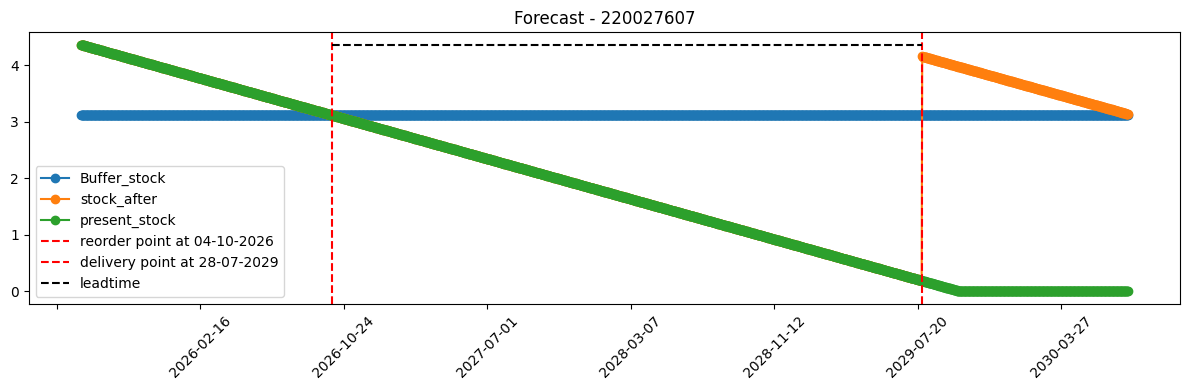

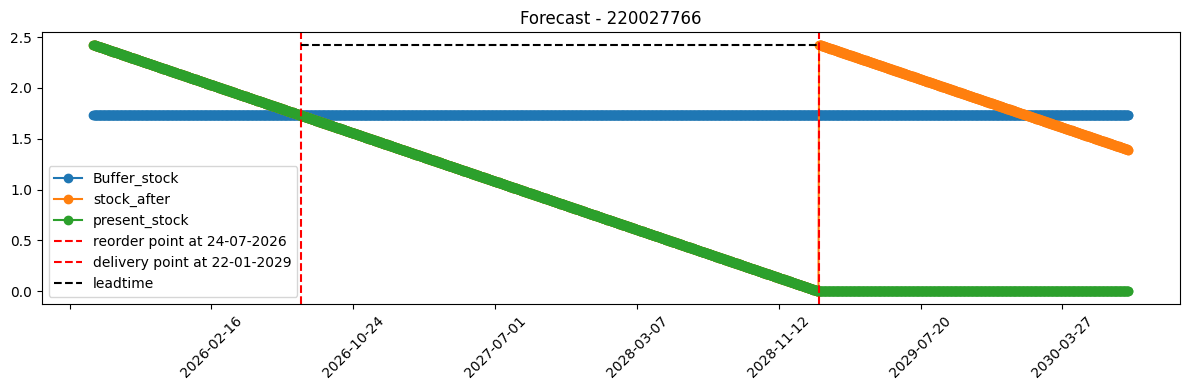

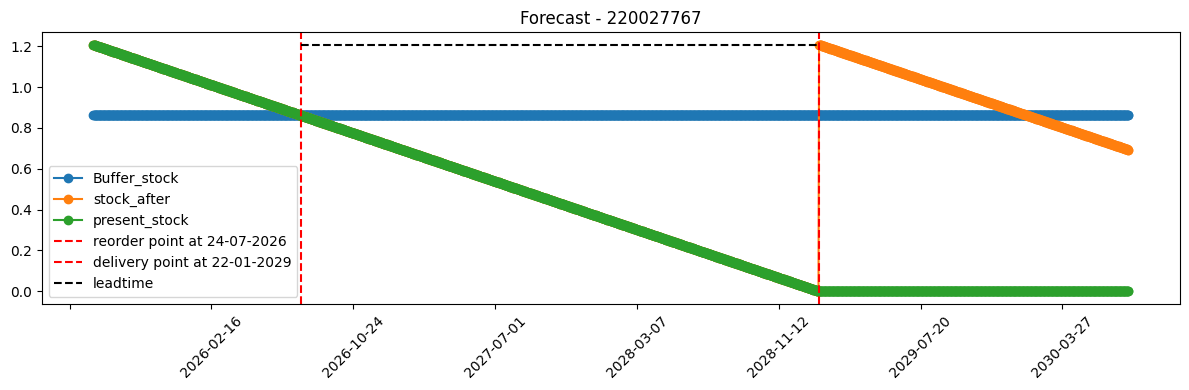

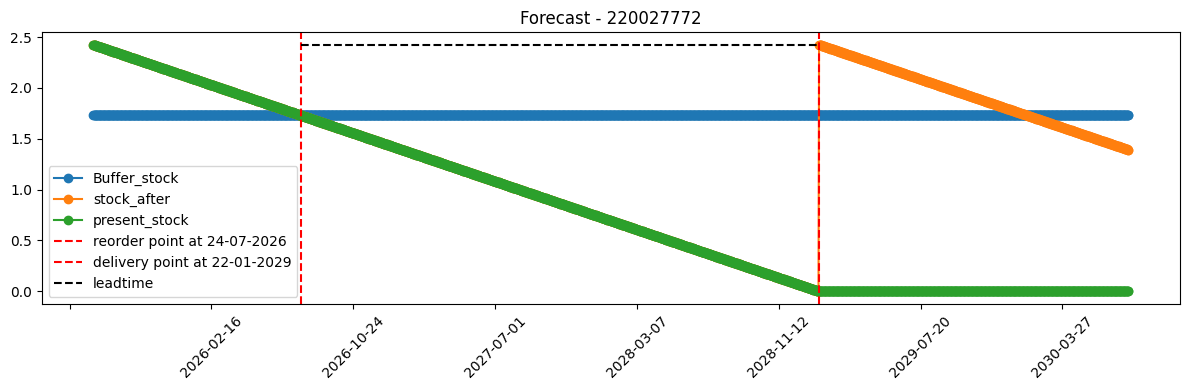

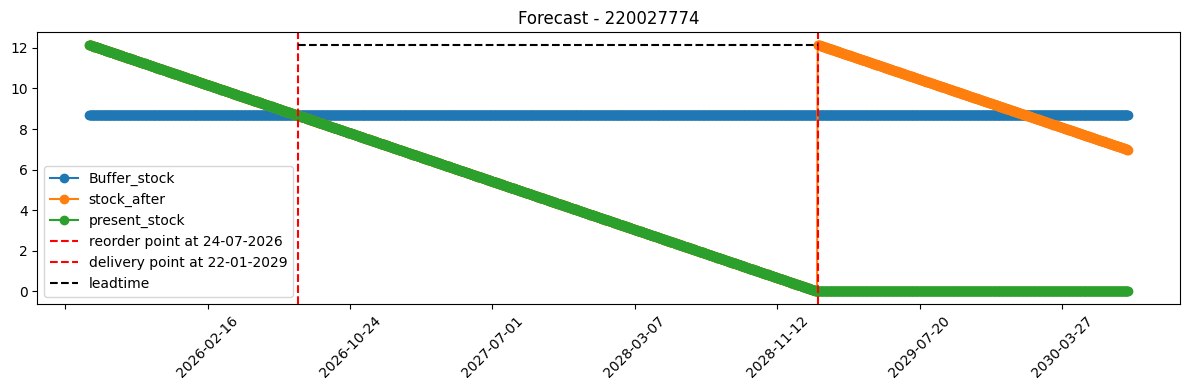

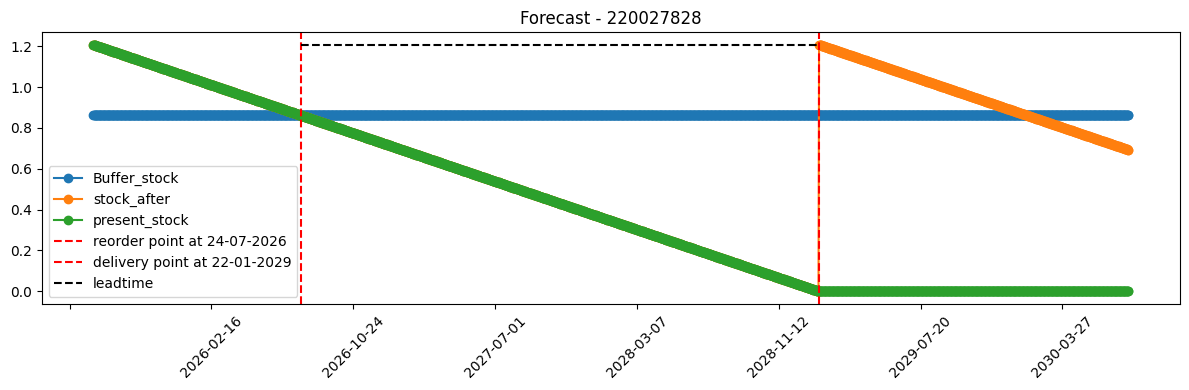

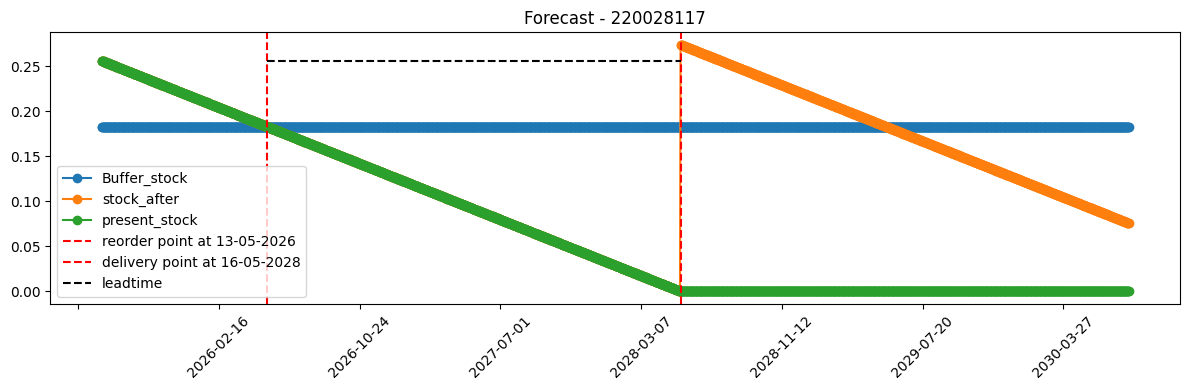

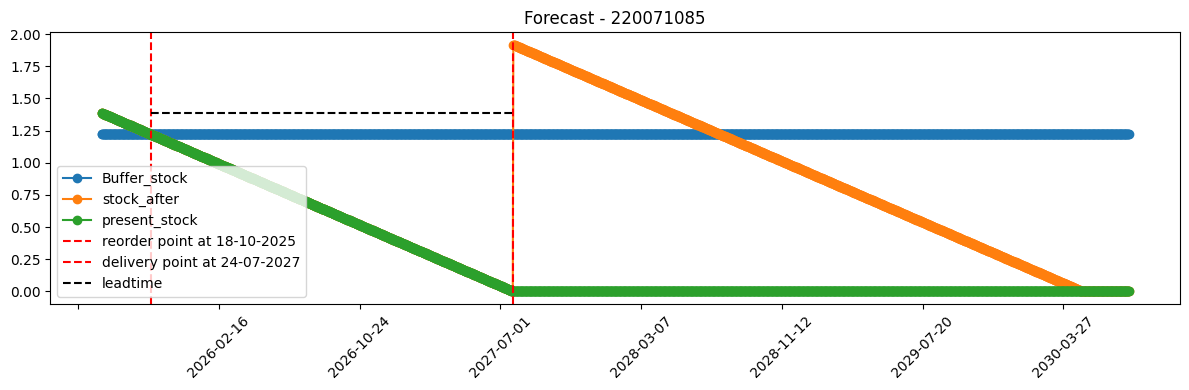

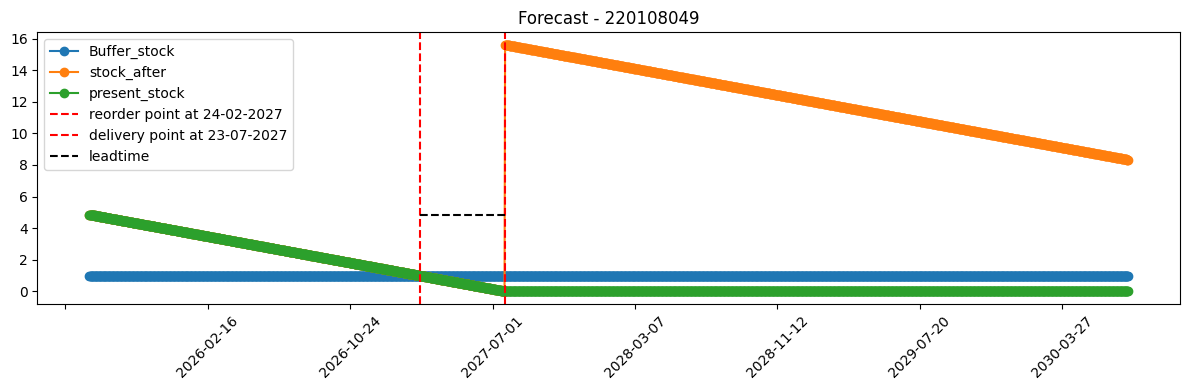

In [29]:
ordering_required={}
for mat in forecasted[forecasted.oem=='ksb'].Material.unique():
    ordering_required[mat]={}
    df, ordering_required[mat] = makedaywiseForecast(forecasted,mat,'ksb')
    plot_req2(df,['Buffer_stock','stock_after','present_stock'],mat,ordering_required[mat]['reorder_point'],int(df.at[0,'leadtime']))

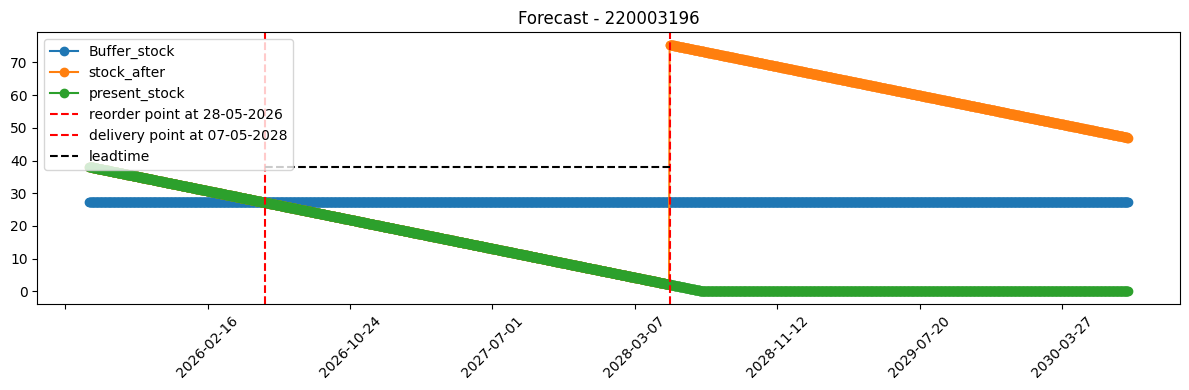

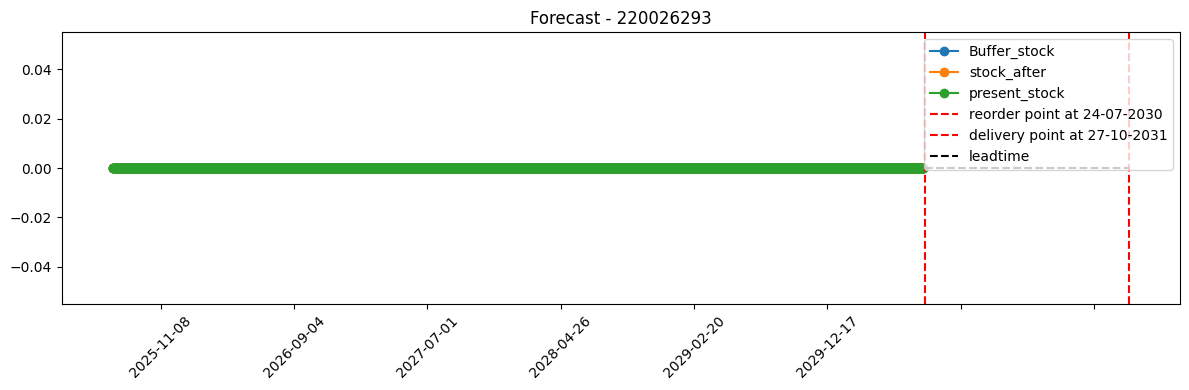

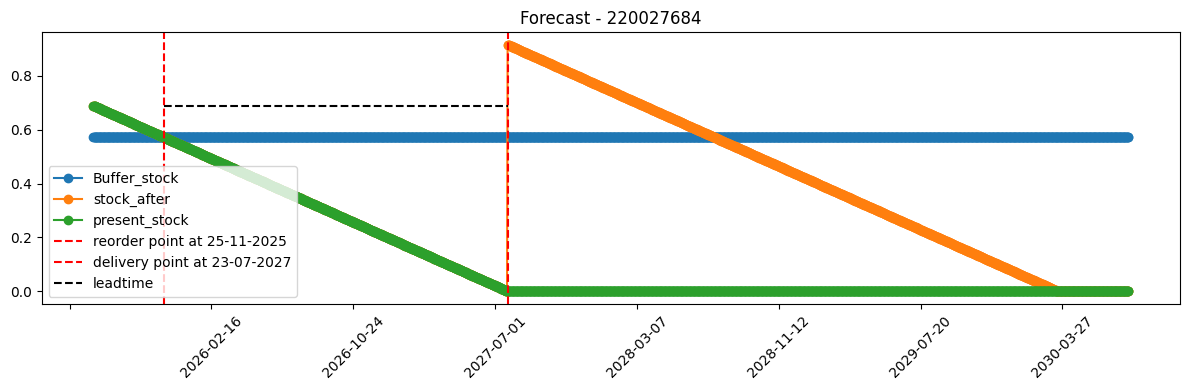

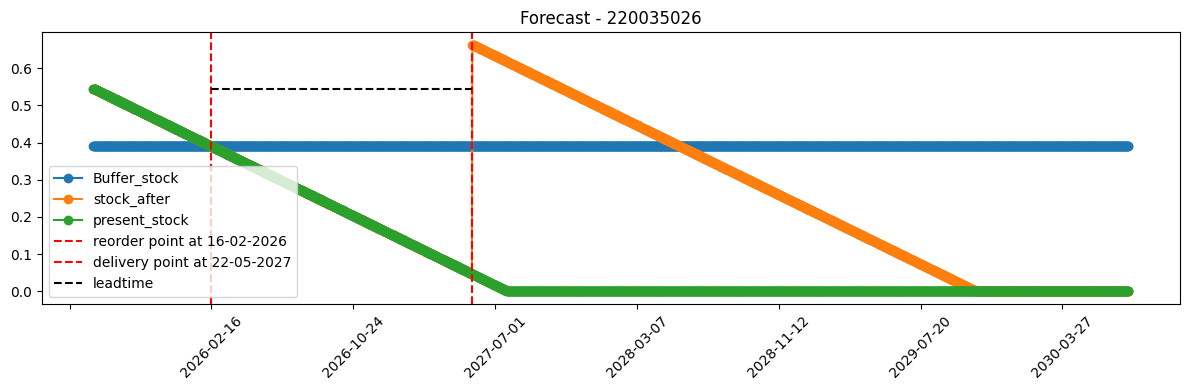

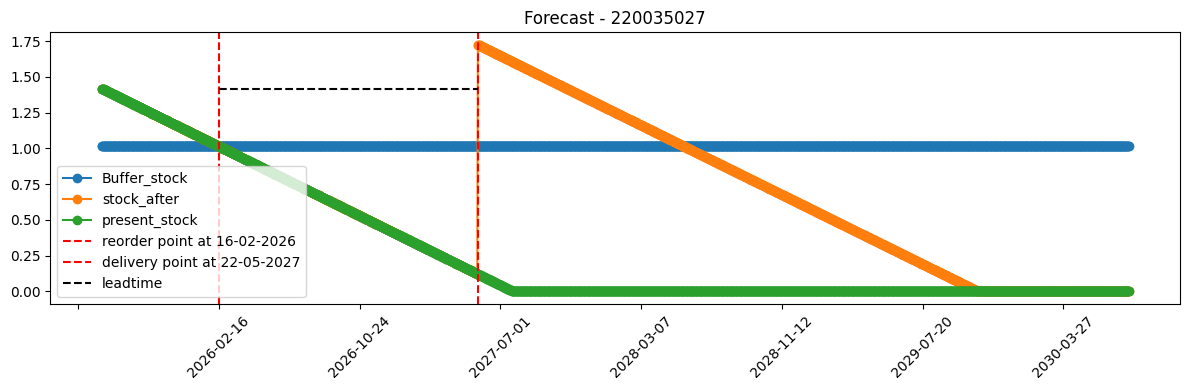

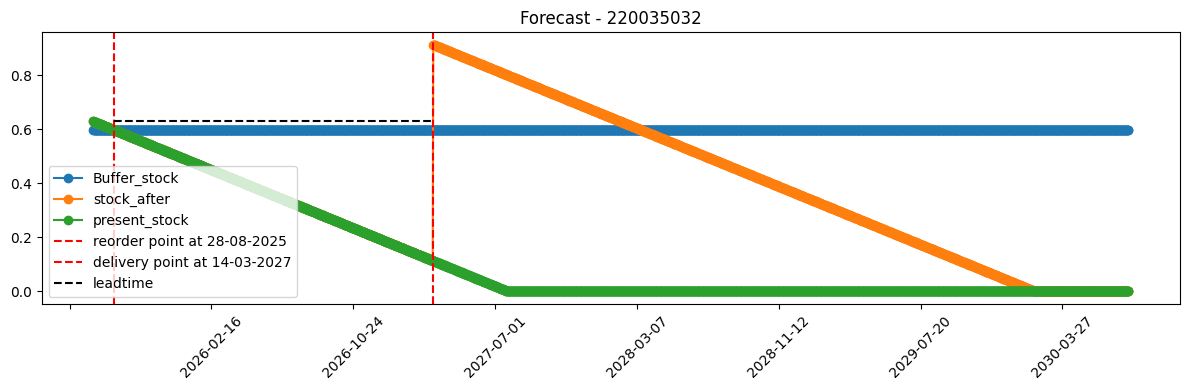

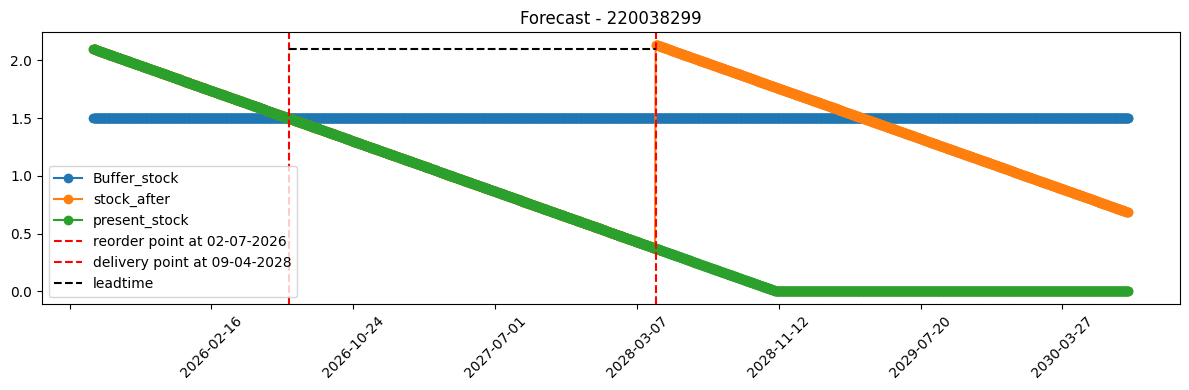

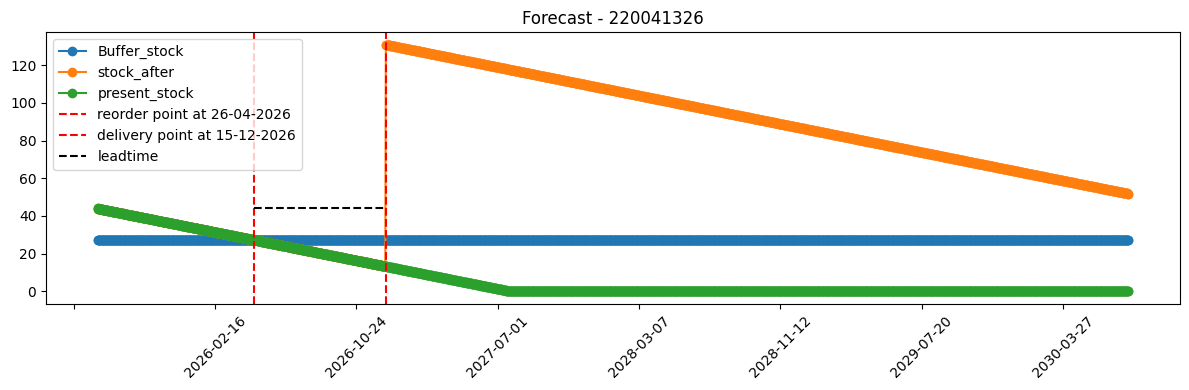

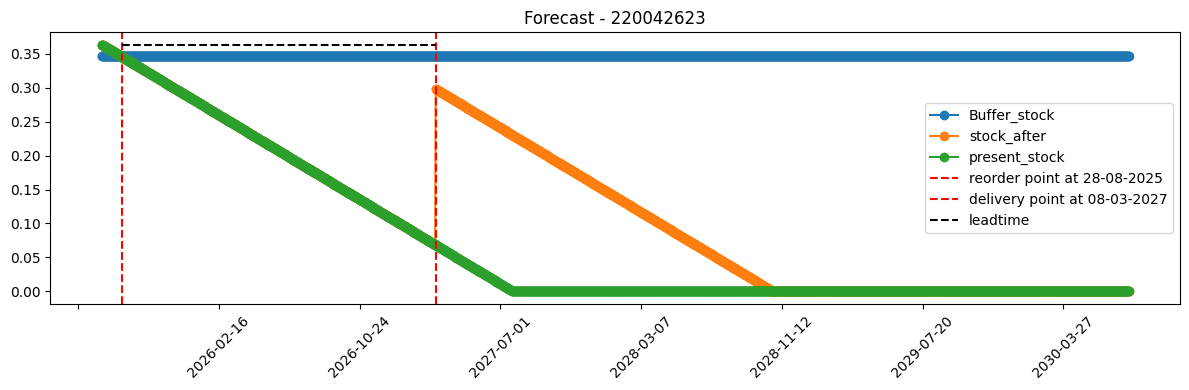

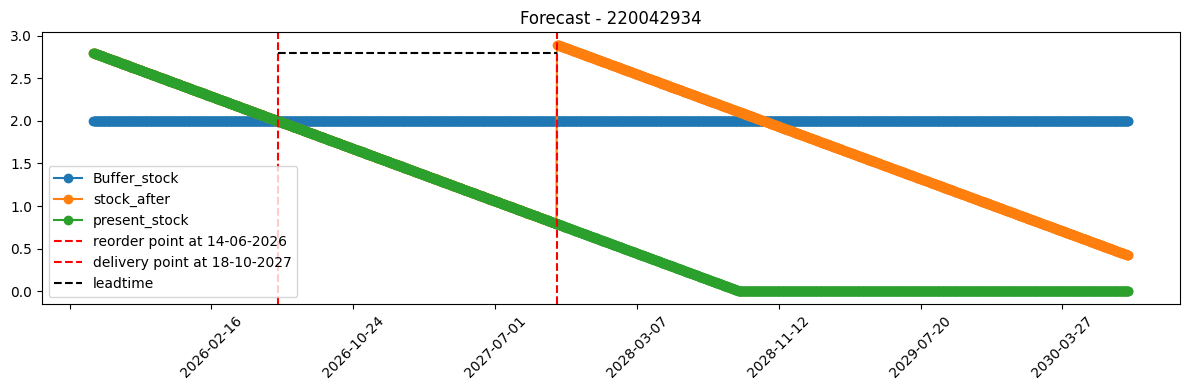

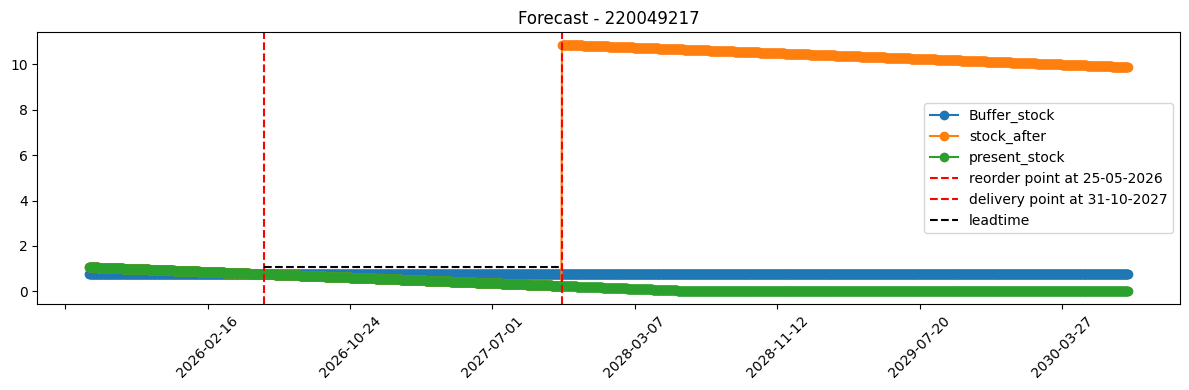

In [30]:
ordering_required={}
for mat in forecasted[forecasted.oem=='atlas'].Material.unique():
    ordering_required[mat]={}
    df, ordering_required[mat] = makedaywiseForecast(forecasted,mat,'atlas')
    plot_req2(df,['Buffer_stock','stock_after','present_stock'],mat,ordering_required[mat]['reorder_point'],int(df.at[0,'leadtime']))